## Notebook objective
This notebook explores how different generation models distribute definitions across lemmas and semantic clusters derived from Sensocomune.

In [ ]:
import pandas as pd
from pathlib import Path

base_path: Path = Path() / ".." / "resources" / "generated" / "DefinitionGeneratorBatch"
base_path = base_path.resolve()
base_path

PosixPath('/Users/manuel/PersonalProjects/isagog-sensocomune/resources/generated/DefinitionGeneratorBatch')

### Data sources and comparison setup
This notebook compares outputs from several generation models on the same lemmas and examines how the number of generated senses varies across semantic clusters.

In [2]:
mistral_jsons: list[Path] = list(
    (base_path / "mistralai%2Fmistral-large-2512").glob("*.json")
)
mistral_jsons[:3]

[PosixPath('/Users/manuel/PersonalProjects/isagog-sensocomune/resources/generated/DefinitionGeneratorBatch/mistralai%2Fmistral-large-2512/00f7d34e2c5f4c0e4a9e337af4b873d984fbea28bb54189cbe0c286ab657fefe.json'),
 PosixPath('/Users/manuel/PersonalProjects/isagog-sensocomune/resources/generated/DefinitionGeneratorBatch/mistralai%2Fmistral-large-2512/1737ad6d9dc6ef86c291f52614ed56255f21ad157d45ac21547a402ae945a74c.json'),
 PosixPath('/Users/manuel/PersonalProjects/isagog-sensocomune/resources/generated/DefinitionGeneratorBatch/mistralai%2Fmistral-large-2512/e13b02a1c1cc6e0b74568a63f0e0b863cc15c59213d2ec3a5fc4438e06b14280.json')]

In [3]:
llama_jsons: list[Path] = list(
    (base_path / "meta-llama%2Fllama-4-scout").glob("*.json")
)
llama_jsons[:3]

[PosixPath('/Users/manuel/PersonalProjects/isagog-sensocomune/resources/generated/DefinitionGeneratorBatch/meta-llama%2Fllama-4-scout/00f7d34e2c5f4c0e4a9e337af4b873d984fbea28bb54189cbe0c286ab657fefe.json'),
 PosixPath('/Users/manuel/PersonalProjects/isagog-sensocomune/resources/generated/DefinitionGeneratorBatch/meta-llama%2Fllama-4-scout/1737ad6d9dc6ef86c291f52614ed56255f21ad157d45ac21547a402ae945a74c.json'),
 PosixPath('/Users/manuel/PersonalProjects/isagog-sensocomune/resources/generated/DefinitionGeneratorBatch/meta-llama%2Fllama-4-scout/e13b02a1c1cc6e0b74568a63f0e0b863cc15c59213d2ec3a5fc4438e06b14280.json')]

In [4]:
qwen_jsons: list[Path] = list(
    (base_path / "qwen%2Fqwen3.6-plus").glob("*.json")
)
qwen_jsons[:3]

[PosixPath('/Users/manuel/PersonalProjects/isagog-sensocomune/resources/generated/DefinitionGeneratorBatch/qwen%2Fqwen3.6-plus/00f7d34e2c5f4c0e4a9e337af4b873d984fbea28bb54189cbe0c286ab657fefe.json'),
 PosixPath('/Users/manuel/PersonalProjects/isagog-sensocomune/resources/generated/DefinitionGeneratorBatch/qwen%2Fqwen3.6-plus/e13b02a1c1cc6e0b74568a63f0e0b863cc15c59213d2ec3a5fc4438e06b14280.json'),
 PosixPath('/Users/manuel/PersonalProjects/isagog-sensocomune/resources/generated/DefinitionGeneratorBatch/qwen%2Fqwen3.6-plus/56833c621cf3b221174af90045ea1d605334af5b4330434f0fc4c5364dc22992.json')]

In [5]:
import json

def load_json(json_path: Path, model_name: str) -> dict:
    data: dict = json.loads(json_path.read_text())
    data["hash_key"] = json_path.stem.removesuffix(".json")
    data["model_name"] = model_name
    return data

In [6]:
mistral_df: pd.DataFrame = pd.DataFrame(
    [load_json(json_path, "mistral-large-2512") for json_path in mistral_jsons]
)
mistral_df.head()

,lemma,lemma_data,senses,hash_key,model_name
0,principe,"{'_id': {'$oid': '648aae6c69ad0a50d065289b'}, ...","[{'pos': 'sostantivo m.', 'definition': 'Titol...",00f7d34e2c5f4c0e4a9e337af4b873d984fbea28bb5418...,mistral-large-2512
1,rimettere,"{'_id': {'$oid': '648aafd169ad0a50d0664d63'}, ...","[{'pos': 'verbo transitivo', 'definition': 'po...",1737ad6d9dc6ef86c291f52614ed56255f21ad157d45ac...,mistral-large-2512
2,edicola,"{'_id': {'$oid': '648aaeb869ad0a50d06568cc'}, ...","[{'pos': 'sostantivo f.', 'definition': 'Picco...",e13b02a1c1cc6e0b74568a63f0e0b863cc15c59213d2ec...,mistral-large-2512
3,gatto,"{'_id': {'$oid': '648aaecf69ad0a50d0657c11'}, ...","[{'pos': 'sostantivo m.', 'definition': 'Picco...",56833c621cf3b221174af90045ea1d605334af5b433043...,mistral-large-2512
4,superare,"{'_id': {'$oid': '648aafe569ad0a50d0665dc6'}, ...","[{'pos': 'verbo transitivo', 'definition': 'an...",a2b2659161f5b1e70ffa3ff635c51d77aef56b1e7f4c31...,mistral-large-2512


In [7]:
llama_df: pd.DataFrame = pd.DataFrame(
    [load_json(json_path, "llama-4-scout") for json_path in llama_jsons]
)
llama_df.head()

,lemma,lemma_data,senses,hash_key,model_name
0,principe,"{'_id': {'$oid': '648aae6c69ad0a50d065289b'}, ...","[{'pos': 'sostantivo maschile', 'definition': ...",00f7d34e2c5f4c0e4a9e337af4b873d984fbea28bb5418...,llama-4-scout
1,rimettere,"{'_id': {'$oid': '648aafd169ad0a50d0664d63'}, ...","[{'pos': 'verbo', 'definition': 'mettere nuova...",1737ad6d9dc6ef86c291f52614ed56255f21ad157d45ac...,llama-4-scout
2,edicola,"{'_id': {'$oid': '648aaeb869ad0a50d06568cc'}, ...","[{'pos': 'sostantivo', 'definition': 'Struttur...",e13b02a1c1cc6e0b74568a63f0e0b863cc15c59213d2ec...,llama-4-scout
3,gatto,"{'_id': {'$oid': '648aaecf69ad0a50d0657c11'}, ...","[{'pos': 'sostantivo', 'definition': 'Mammifer...",56833c621cf3b221174af90045ea1d605334af5b433043...,llama-4-scout
4,superare,"{'_id': {'$oid': '648aafe569ad0a50d0665dc6'}, ...","[{'pos': 'verbo', 'definition': 'muoversi oltr...",a2b2659161f5b1e70ffa3ff635c51d77aef56b1e7f4c31...,llama-4-scout


In [8]:
qwen_df: pd.DataFrame = pd.DataFrame(
    [load_json(json_path, "qwen3.6-plus") for json_path in qwen_jsons]
)
qwen_df.head()

,lemma,lemma_data,senses,hash_key,model_name
0,principe,"{'_id': {'$oid': '648aae6c69ad0a50d065289b'}, ...","[{'pos': 'sostantivo m.', 'definition': 'Titol...",00f7d34e2c5f4c0e4a9e337af4b873d984fbea28bb5418...,qwen3.6-plus
1,edicola,"{'_id': {'$oid': '648aaeb869ad0a50d06568cc'}, ...","[{'pos': 'sostantivo femminile', 'definition':...",e13b02a1c1cc6e0b74568a63f0e0b863cc15c59213d2ec...,qwen3.6-plus
2,gatto,"{'_id': {'$oid': '648aaecf69ad0a50d0657c11'}, ...","[{'pos': 'sostantivo m.', 'definition': 'Picco...",56833c621cf3b221174af90045ea1d605334af5b433043...,qwen3.6-plus
3,superare,"{'_id': {'$oid': '648aafe569ad0a50d0665dc6'}, ...","[{'pos': 'verbo transitivo', 'definition': 'At...",a2b2659161f5b1e70ffa3ff635c51d77aef56b1e7f4c31...,qwen3.6-plus
4,saluto,"{'_id': {'$oid': '648aaf3e69ad0a50d065d6a2'}, ...","[{'pos': 'sostantivo, m.', 'definition': 'Atto...",d6374b8f4813da118fbf02f4cd2fcb46e7b4e12d9e3723...,qwen3.6-plus


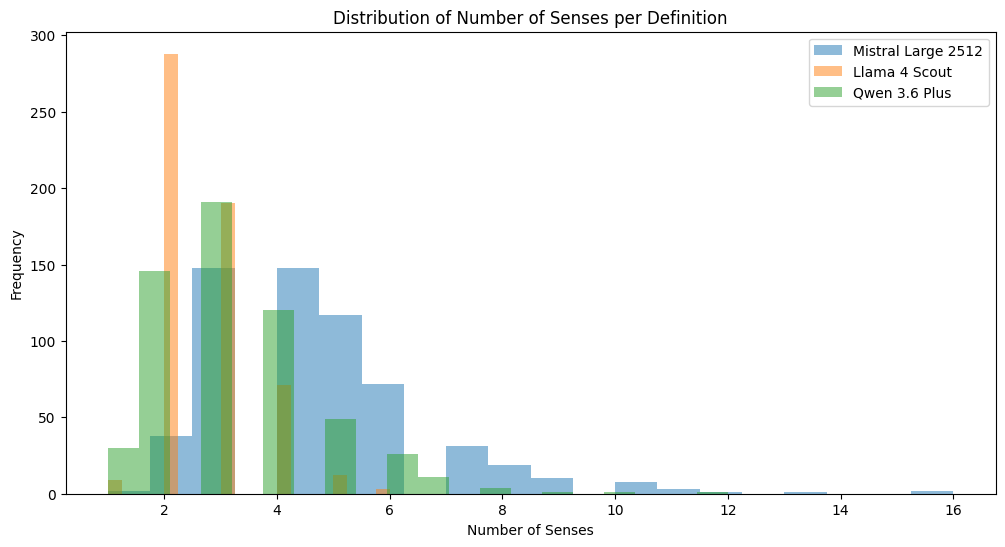

In [9]:
# Compare "len" distribution of "senses" column across the three dataframes
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.hist(mistral_df["senses"].apply(len), bins=20, alpha=0.5, label="Mistral Large 2512")
plt.hist(llama_df["senses"].apply(len), bins=20, alpha=0.5, label="Llama 4 Scout")
plt.hist(qwen_df["senses"].apply(len), bins=20, alpha=0.5, label="Qwen 3.6 Plus")
plt.xlabel("Number of Senses")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Senses per Definition")
plt.legend()
plt.show()

In [ ]:
tdm_sampled: list[dict] = json.loads(Path("../resources/sensocomune/tdm.sampled.json").read_text())
tdm_sampled_indicized: dict = {
    item["lemma"]: item for item in tdm_sampled
}

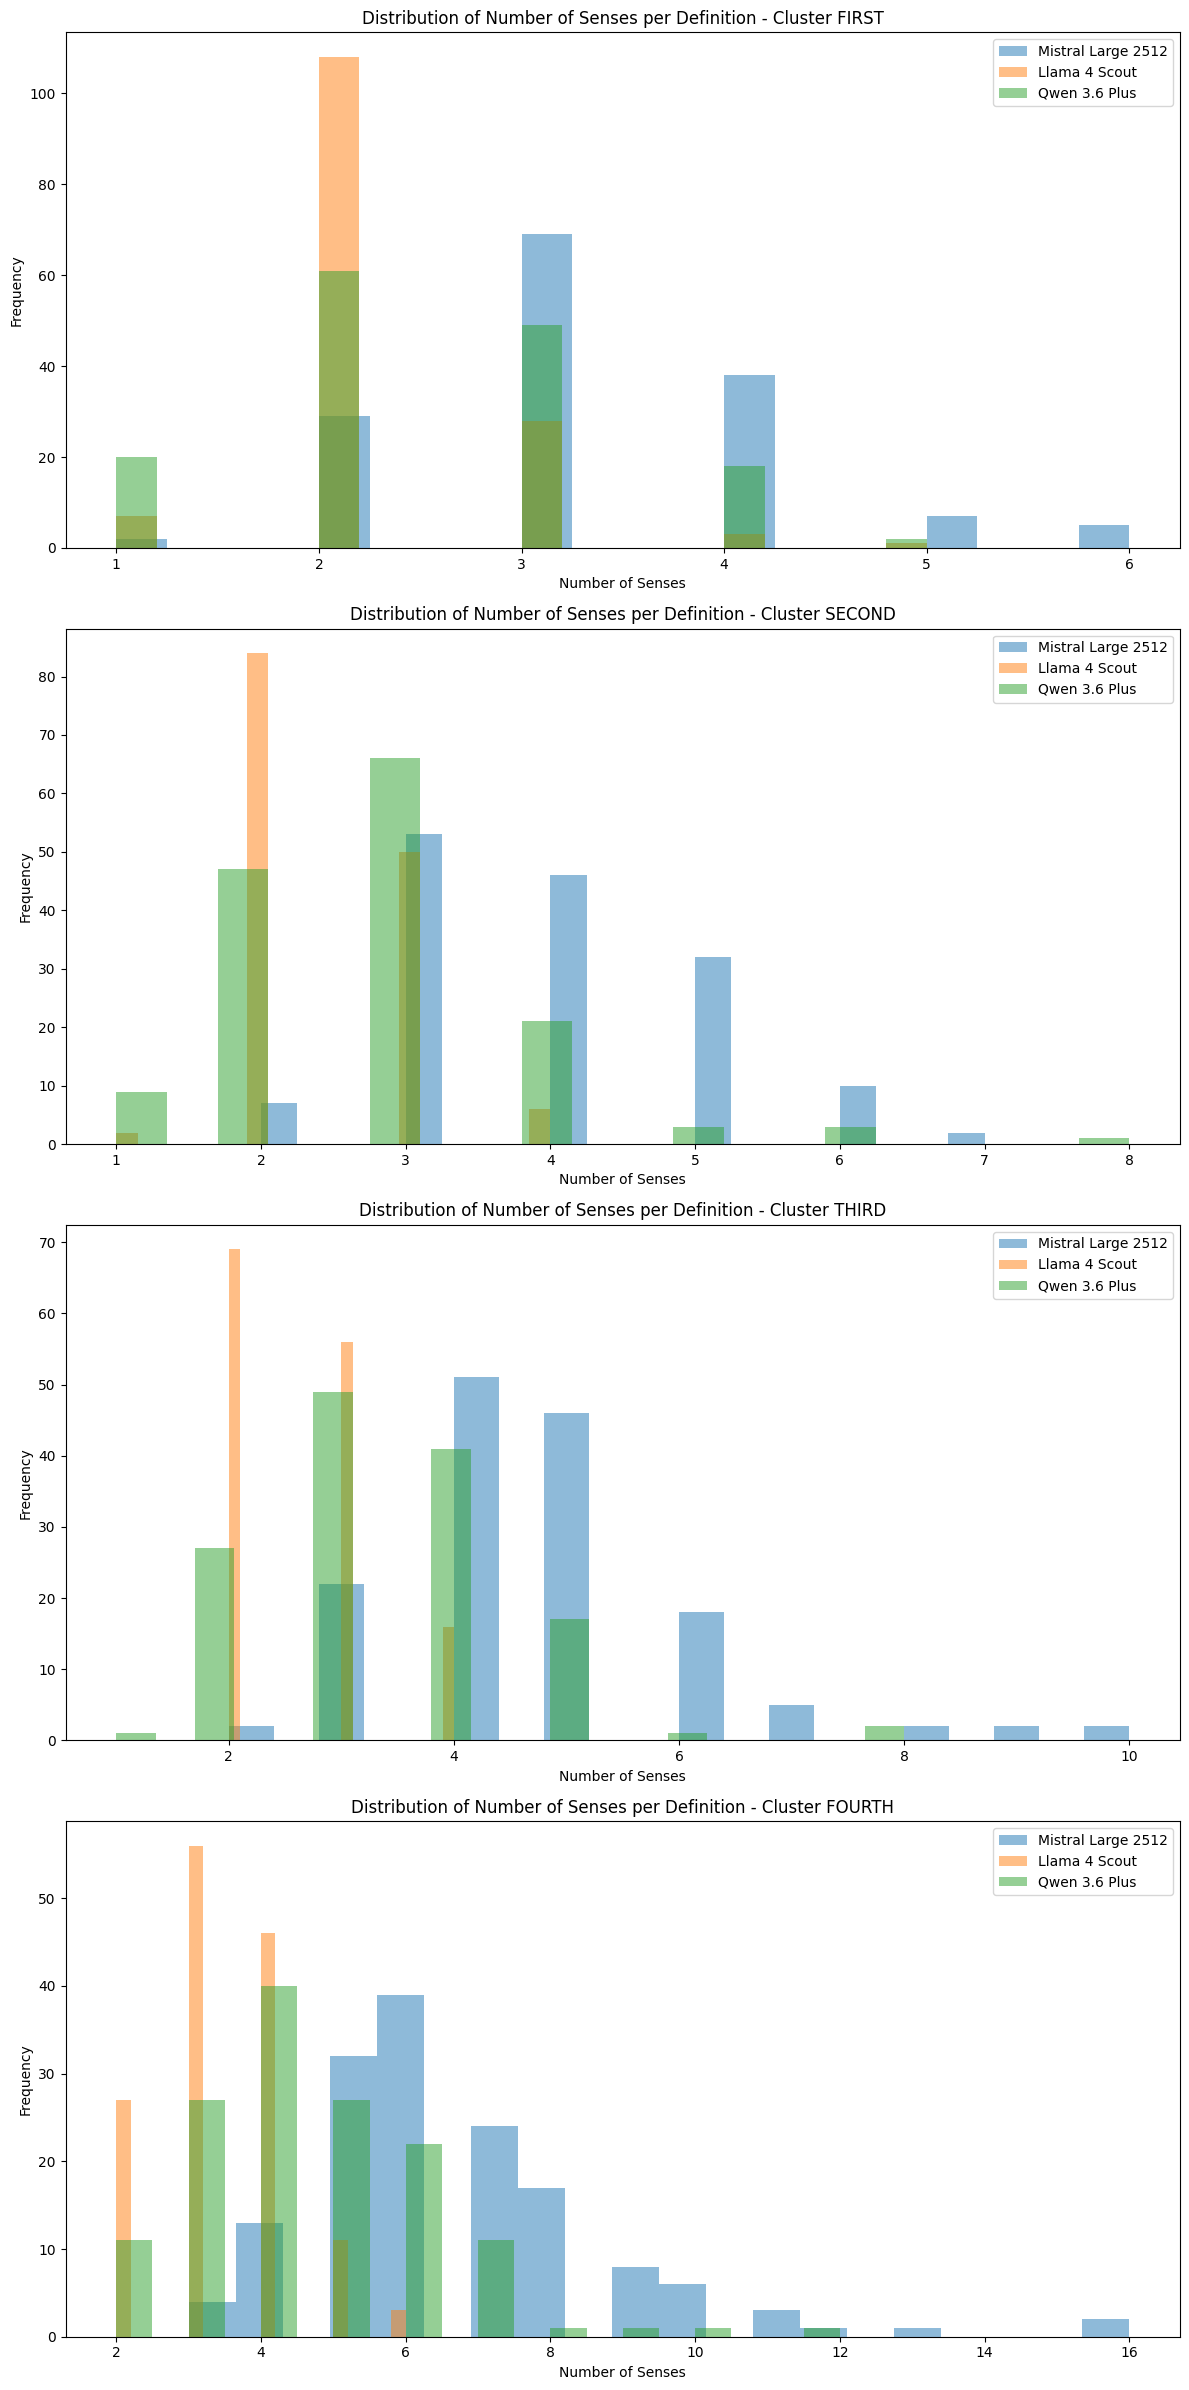

In [11]:
mistral_df["cluster"] = mistral_df["lemma_data"].apply(
    lambda x: tdm_sampled_indicized[x["lemma"]]["cluster"]
)
llama_df["cluster"] = llama_df["lemma_data"].apply(
    lambda x: tdm_sampled_indicized[x["lemma"]]["cluster"]
)
qwen_df["cluster"] = qwen_df["lemma_data"].apply(
    lambda x: tdm_sampled_indicized[x["lemma"]]["cluster"]
)
# Plot generated senses per cluster for each model doing subplots sort by "FIRST", "SECOND", "THIRD", "FOURTH"
clusters = ["FIRST", "SECOND", "THIRD", "FOURTH"]
fig, axes = plt.subplots(len(clusters), 1, figsize=(12, 6 * len(clusters)))
for i, cluster in enumerate(clusters):
    ax = axes[i]
    mistral_cluster = mistral_df[mistral_df["cluster"] == cluster]
    llama_cluster = llama_df[llama_df["cluster"] == cluster]
    qwen_cluster = qwen_df[qwen_df["cluster"] == cluster]
    ax.hist(mistral_cluster["senses"].apply(len), bins=20, alpha=0.5, label="Mistral Large 2512")
    ax.hist(llama_cluster["senses"].apply(len), bins=20, alpha=0.5, label="Llama 4 Scout")
    ax.hist(qwen_cluster["senses"].apply(len), bins=20, alpha=0.5, label="Qwen 3.6 Plus")
    ax.set_xlabel("Number of Senses")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of Number of Senses per Definition - Cluster {cluster}")
    ax.legend()
plt.tight_layout()
plt.show()

In [12]:
len(mistral_df), len(llama_df), len(qwen_df)

(600, 573, 580)